In [1]:
# Install required libraries
!pip install shap transformers datasets torch scikit-learn

# Import required libraries
import re
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from datasets import Dataset
from transformers import XLMRobertaTokenizerFast, XLMRobertaForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import torch

# Ensure GPU is used if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Predefined list of German stopwords
german_stopwords = set([
    # Add German stopwords here if needed
])

# Preprocess the text
def preprocess_text(text):
    text = re.sub(r'\S+@\S+\.\S+', '', text)  # Remove emails
    text = re.sub(r'[^A-Za-zäöüß ]+', '', text)  # Remove special characters and numbers
    text = text.lower()  # Convert to lowercase
    text = ' '.join([word for word in text.split() if word not in german_stopwords])  # Remove stopwords
    return text

# Load the dataset
dataset = pd.read_csv("gahd_filtered.csv")

# Check label distribution
print("Original Label Distribution:", dataset['label'].value_counts())

# Apply preprocessing
dataset["text"] = dataset["text"].apply(preprocess_text)

# Handle class imbalance
majority_class = dataset[dataset["label"] == 0]
minority_class = dataset[dataset["label"] == 1]

minority_upsampled = resample(
    minority_class,
    replace=True,
    n_samples=len(majority_class),
    random_state=42
)

balanced_dataset = pd.concat([majority_class, minority_upsampled]).sample(frac=1, random_state=42)

# Check new label distribution
print("Balanced Label Distribution:", balanced_dataset['label'].value_counts())

# Split into training and test sets
train_df, test_df = train_test_split(balanced_dataset, test_size=0.2, random_state=42, stratify=balanced_dataset["label"])
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Tokenizer and model
model_name = "xlm-roberta-base"
tokenizer = XLMRobertaTokenizerFast.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

train_tokenized = train_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

train_tokenized = train_tokenized.remove_columns(["text", "__index_level_0__"])
test_tokenized = test_tokenized.remove_columns(["text", "__index_level_0__"])

train_tokenized = train_tokenized.rename_column("label", "labels")
test_tokenized = test_tokenized.rename_column("label", "labels")

train_tokenized.set_format("torch")
test_tokenized.set_format("torch")

# Define metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
    }

# Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    learning_rate=3e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    save_total_limit=2,
)

# Model
model = XLMRobertaForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

# Train the model
trainer.train()

# Save the model and tokenizer
model.save_pretrained("./saved_model")
tokenizer.save_pretrained("./saved_model")

# Evaluate the model
eval_results = trainer.evaluate()
print(f"Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"F1-Score: {eval_results['eval_f1']:.4f}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 13.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.
Using device: cuda
Original Label Distribution: label
0    6330
1    4666
Name: count, dtype: int64
Balanced Label Distribution: label
0    6330
1    6330
Name: c

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

Map:   0%|          | 0/10128 [00:00<?, ? examples/s]

Map:   0%|          | 0/2532 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.674200,0.593015,0.694708,0.680883,0.735519,0.694708
2,0.595500,0.522205,0.747235,0.745020,0.756136,0.747235
3,0.527000,0.470146,0.780411,0.777410,0.796395,0.780411
4,0.402600,0.475311,0.794629,0.794622,0.794665,0.794629
5,0.342600,0.449956,0.811611,0.810243,0.820865,0.811611


Accuracy: 0.8116
F1-Score: 0.8102


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
You are using a model of type xlm-roberta to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ./saved_model and are newly initialized: ['classifier.bias', 'classifier.weight', 'embeddings.LayerNorm.bias', 'embeddings.LayerNorm.weight', 'embeddings.position_embeddings.weight', 'embeddings.token_type_embeddings.weight', 'embeddings.word_embeddings.weight', 'encoder.layer.0.attention.output.LayerNorm.bias', 'encoder.layer.0.attention.output.LayerNorm.weight', 'encoder.layer.0.attention.output.dense.bias', 'encoder.layer.0.attention.output.dense.weight', 'encoder.layer.0.attention.self.key.bias', 'enc

Sample Texts from Dataset:
Sample 1: Ich mag Sterne. Morgensterne, (sehr wirkungsvoll), Abendsterne (sehr schön), Filmsternchen (ebenfalls sehr schön und talentiert). Nur Judensterne nicht
Sample 2: So viele Nazis, die ein Problem mit Juden hatten, gibt es heute noch, sie verstecken sich wie ich
Sample 3: Im Zweiten Vatikanischen Konzil heißt es: „Man darf nicht als Liebesgabe anbieten, was schon aus Gerechtigkeit geschuldet ist.“
Sample 4: Der beachtliche Anteil an Moslems in meiner Stadt ist in kultureller Hinsicht enorm gewinnbringend für die Bevölkerung.


PartitionExplainer explainer: 5it [00:10, 10.20s/it]               


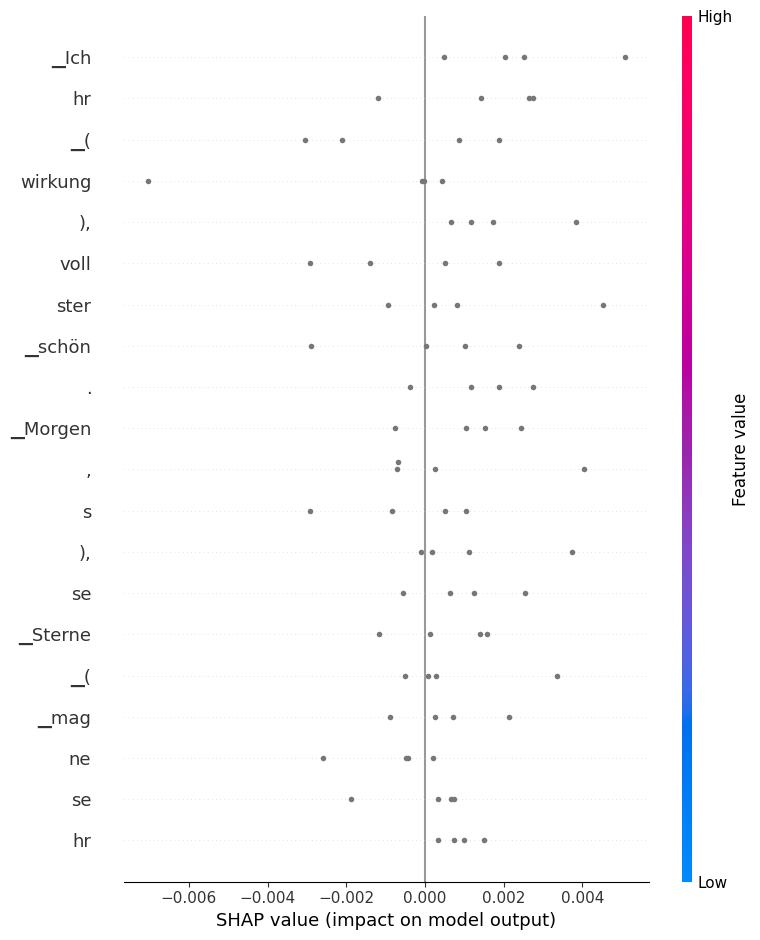


Force Plot for Sample 1: Ich mag Sterne. Morgensterne, (sehr wirkungsvoll), Abendsterne (sehr schön), Filmsternchen (ebenfalls sehr schön und talentiert). Nur Judensterne nicht


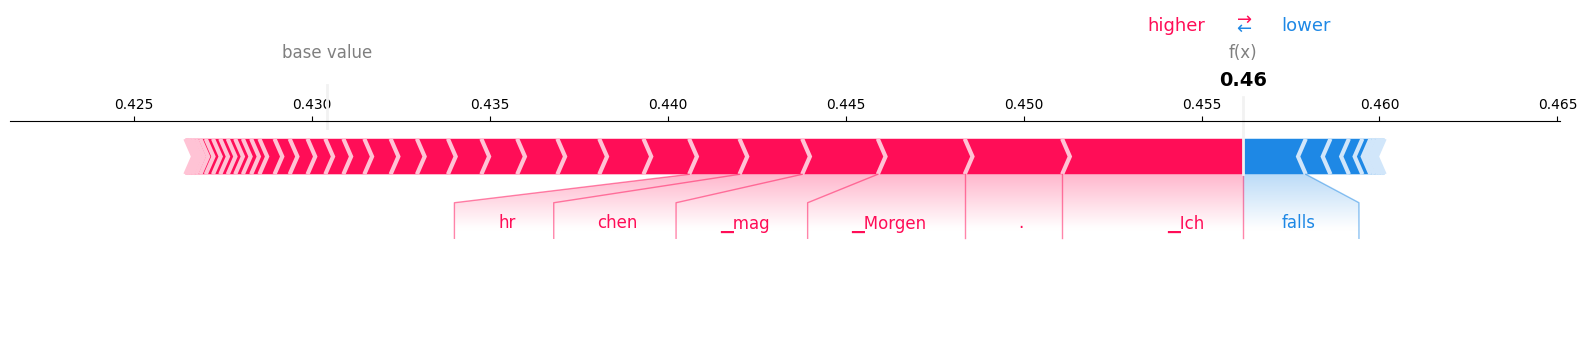


Force Plot for Sample 2: So viele Nazis, die ein Problem mit Juden hatten, gibt es heute noch, sie verstecken sich wie ich


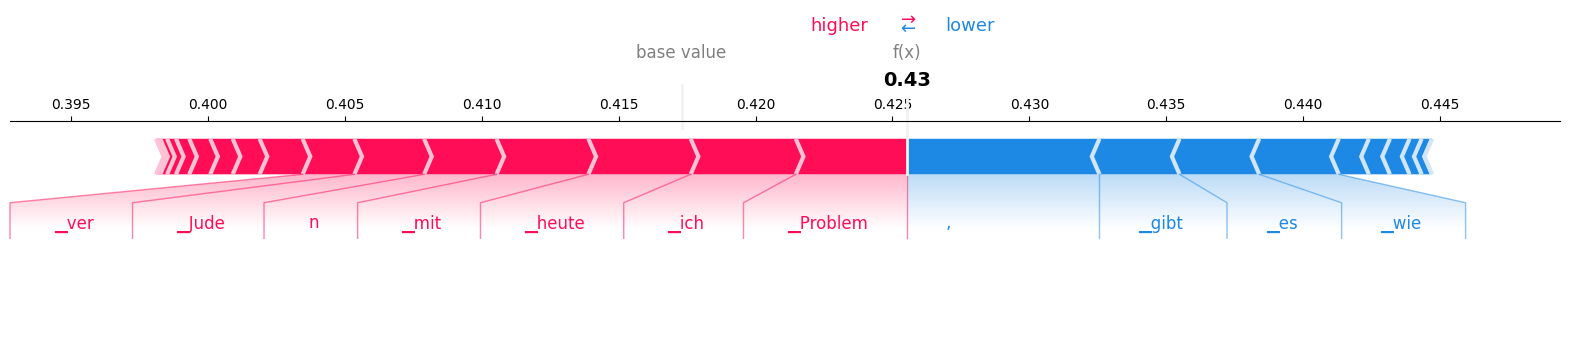


Force Plot for Sample 3: Im Zweiten Vatikanischen Konzil heißt es: „Man darf nicht als Liebesgabe anbieten, was schon aus Gerechtigkeit geschuldet ist.“


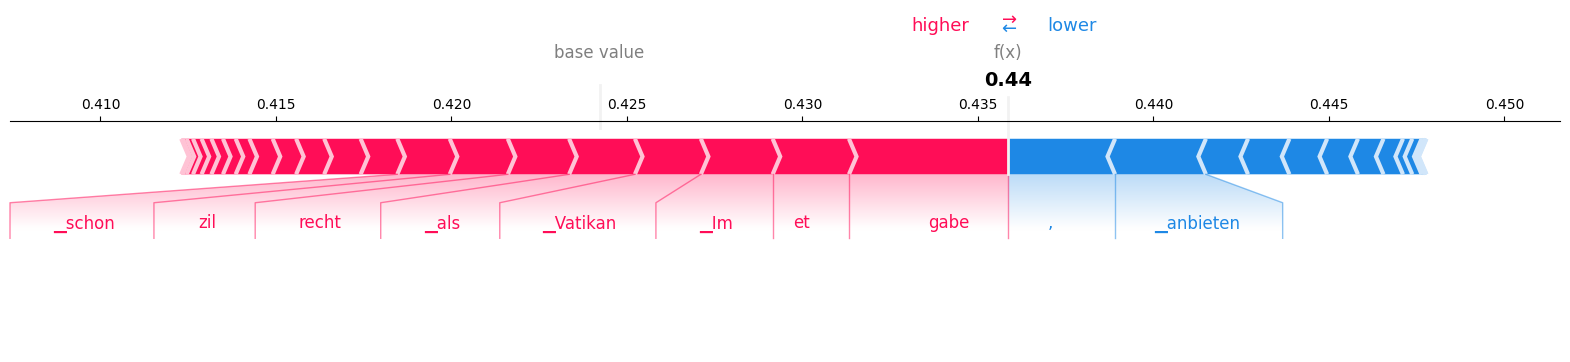


Force Plot for Sample 4: Der beachtliche Anteil an Moslems in meiner Stadt ist in kultureller Hinsicht enorm gewinnbringend für die Bevölkerung.


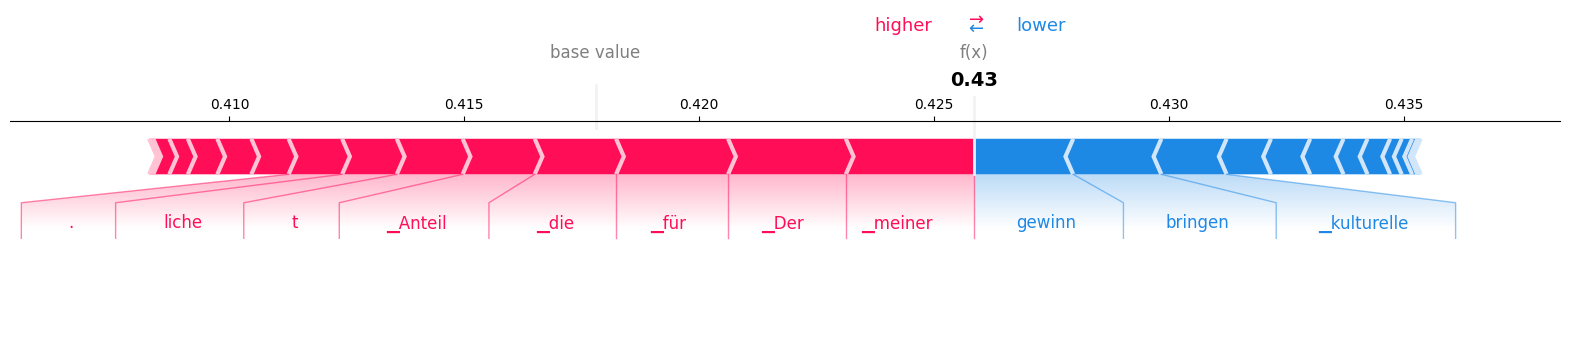


Top 10 Most Important Features (Tokens):
Token: ▁Ich, Importance: 0.0025
Token: hr, Importance: 0.0020
Token: ▁(, Importance: 0.0020
Token: wirkung, Importance: 0.0019
Token: ),, Importance: 0.0019
Token: voll, Importance: 0.0017
Token: ster, Importance: 0.0016
Token: ▁schön, Importance: 0.0016
Token: ., Importance: 0.0015
Token: ▁Morgen, Importance: 0.0014

Feature importance saved to 'feature_importance.csv'.


In [31]:
# Install required libraries
!pip install shap transformers torch nltk

# Download required NLTK data
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

# Import required libraries
import shap
import torch
import numpy as np
import csv
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from transformers import BertTokenizerFast, BertForSequenceClassification
import pandas as pd
from sklearn.model_selection import train_test_split
import re

# Load German stop words
german_stop_words = set(stopwords.words('german'))

# Function to remove German stop words
def remove_stopwords(text):
    words = word_tokenize(text, language='german')
    filtered_words = [word for word in words if word.lower() not in german_stop_words]
    return " ".join(filtered_words)

def remove_special_chars(text):
    """Removes specified special characters from the given text, including nested brackets."""
    # Extended pattern to handle nested brackets and various special characters
    pattern = r"[.,;()\[\]{}!?:@#$%^&*()_+-=<>?/]"
    # Replace multiple consecutive whitespace characters with a single space
    text = re.sub(r'\s+', ' ', text)
    # Remove special characters
    return re.sub(pattern, '', text)

# Load the trained model and tokenizer
model = BertForSequenceClassification.from_pretrained("./saved_model")
tokenizer = BertTokenizerFast.from_pretrained("./saved_model")
model.to("cuda" if torch.cuda.is_available() else "cpu")

# Define predict_proba for SHAP
def predict_proba(texts):
    if isinstance(texts, str):
        texts = [texts]
    elif isinstance(texts, np.ndarray):
        texts = texts.tolist()
    elif not isinstance(texts, list) or not all(isinstance(t, str) for t in texts):
        raise ValueError(f"Unexpected input format: {type(texts)}")

    # Apply stop word removal and special character removal
    texts = [remove_stopwords(remove_special_chars(text)) for text in texts]

    inputs = tokenizer(
        texts, truncation=True, max_length=128, padding=True, return_tensors="pt"
    ).to("cuda" if torch.cuda.is_available() else "cpu")

    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.nn.functional.softmax(logits, dim=1)
    return probs.cpu().numpy()

# Load dataset
data = pd.read_csv('gahd_filtered.csv')
train_df, test_df = train_test_split(data, test_size=0.2, random_state=42)

# Initialize SHAP Explainer with Text Masker
masker = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(predict_proba, masker)

# Select random sample texts from the test dataset
sample_texts = test_df.sample(4, random_state=42)["text"].tolist()

# Print sample texts
print("Sample Texts from Dataset:")
for i, text in enumerate(sample_texts, 1):
    print(f"Sample {i}: {text}")

# Compute SHAP values
shap_values = explainer(sample_texts)

# Extract tokens and SHAP values, ensuring consistent length
max_len = 128
normalized_shap_values = []
normalized_tokens = []
for sample, value in zip(sample_texts, shap_values):
    tokens = tokenizer.convert_ids_to_tokens(tokenizer(sample, truncation=True, max_length=max_len, padding=True)['input_ids'])
    shap_vals = value.values[:, 1]

    normalized_shap_values.append(
        np.pad(shap_vals, (0, max_len - len(shap_vals)), constant_values=0)[:max_len]
    )
    normalized_tokens.append(tokens[:max_len] + ['[PAD]'] * (max_len - len(tokens[:max_len])))

# Filter out [PAD] tokens before visualization
filtered_shap_results = []
for shap_values_row, tokens_row in zip(normalized_shap_values, normalized_tokens):
    filtered_shap_values = [val for val, token in zip(shap_values_row, tokens_row) if token != '[PAD]']
    filtered_tokens = [token for token in tokens_row if token != '[PAD]']
    filtered_shap_results.append((filtered_shap_values, filtered_tokens))

# Pad SHAP values to equal length for visualization
max_len_filtered = max(len(result[0]) for result in filtered_shap_results)
padded_shap_values = [np.pad(result[0], (0, max_len_filtered - len(result[0])), constant_values=0) for result in filtered_shap_results]

# Pad tokens for visualization
padded_tokens = [result[1] + ['[PAD]'] * (max_len_filtered - len(result[1])) for result in filtered_shap_results]

# SHAP Summary Plot
shap.initjs()
shap.summary_plot(
    shap_values=np.array(padded_shap_values),
    features=np.array(padded_tokens),
    feature_names=padded_tokens[0],
)

# SHAP Force Plot
for i, text in enumerate(sample_texts):
    print(f"\nForce Plot for Sample {i + 1}: {text}")
    expected_value = explainer.expected_value[1] if explainer.expected_value is not None else predict_proba([text])[0][1]
    tokens = tokenizer.convert_ids_to_tokens(tokenizer(text, truncation=True, max_length=max_len, padding=True)['input_ids'])
    shap.force_plot(
        expected_value,
        shap_values[i].values[:, 1],
        features=tokens,
        matplotlib=True
    )

# Calculate global feature importance
feature_importance = np.mean(np.abs(normalized_shap_values), axis=0)
feature_importance_data = list(zip(normalized_tokens[0], feature_importance))

# Sort tokens by importance
sorted_feature_importance = sorted(feature_importance_data, key=lambda x: x[1], reverse=True)

# Display top 10 most important features
print("\nTop 10 Most Important Features (Tokens):")
for token, importance in sorted_feature_importance[:10]:
    print(f"Token: {token}, Importance: {importance:.4f}")

# Save feature importance to CSV
with open("feature_importance.csv", "w") as f:
    writer = csv.writer(f)
    writer.writerow(["Token", "Importance"])
    writer.writerows(sorted_feature_importance)

print("\nFeature importance saved to 'feature_importance.csv'.")

In [42]:
!pip freeze > requirements.txt

In [43]:
!zip -r /content/my_content.zip /content/

  adding: content/ (stored 0%)
  adding: content/.config/ (stored 0%)
  adding: content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db (deflated 97%)
  adding: content/.config/config_sentinel (stored 0%)
  adding: content/.config/.last_opt_in_prompt.yaml (stored 0%)
  adding: content/.config/default_configs.db (deflated 98%)
  adding: content/.config/.last_update_check.json (deflated 23%)
  adding: content/.config/gce (stored 0%)
  adding: content/.config/active_config (stored 0%)
  adding: content/.config/.last_survey_prompt.yaml (stored 0%)
  adding: content/.config/logs/ (stored 0%)
  adding: content/.config/logs/2025.01.16/ (stored 0%)
  adding: content/.config/logs/2025.01.16/14.28.59.271536.log (deflated 58%)
  adding: content/.config/logs/2025.01.16/14.28.29.838121.log (deflated 93%)
  adding: content/.config/logs/2025.01.16/14.29.08.514080.log (deflated 57%)
  adding: content/.config/logs/2025.01.16/14.28.58.277099.log (deflated 87%)
  adding: content/.c